# Notebook 1: Data loading and exploratory analysis

**Project:** Cross-Domain Spam Detection  
**Research question:** Can a spam classifier trained on SMS messages generalize to emails?

This notebook loads two independent Hugging Face datasets, standardizes their schema, creates reproducible splits, and verifies that the data is leakage-free before modeling. It runs in VS Code or Kaggle.

## Datasets and decisions

- [jngb-labs/sms-spam](https://huggingface.co/datasets/jngb-labs/sms-spam): short SMS messages.
- [SetFit/enron_spam](https://huggingface.co/datasets/SetFit/enron_spam): longer email messages.

Both datasets are standardized to `text`, `label`, and `source`, with `0 = ham` and `1 = spam`. Cleaning is deliberately conservative: whitespace is normalized and empty or duplicate texts are removed, while punctuation, capitalization, URLs, and numbers are preserved as potential spam signals.

In [1]:
from pathlib import Path
import subprocess
import sys

REPOSITORY_URL = 'https://github.com/kbozukov-coke/cross-domain-spam-detection.git'
PROJECT_NAME = 'cross-domain-spam-detection'
IS_KAGGLE = Path('/kaggle/working').exists()

if IS_KAGGLE:
    PROJECT_ROOT = Path('/kaggle/working') / PROJECT_NAME
    if not (PROJECT_ROOT / 'src').exists():
        subprocess.run(
            ['git', 'clone', '--depth', '1', REPOSITORY_URL, str(PROJECT_ROOT)],
            check=True,
        )
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import LABEL_NAMES, load_prepared_splits, summarize_splits

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42
print(f'Running in: {"Kaggle" if IS_KAGGLE else "local environment"}')

Running in: local environment


## 1. Load, clean, and split

SMS is split 70/15/15 with stratification to preserve the class ratio. Enron's published test set is kept unchanged, while 15% of its training data is reserved for validation.

In [2]:
splits, cleaning_audit = load_prepared_splits(random_state=RANDOM_STATE)
cleaning_audit

,dataset_part,raw_rows,clean_rows,empty_removed,conflicting_removed,duplicates_removed,train_test_overlap_removed
0,sms_all,5159,5159,0,0,0,0
1,enron_train,31716,28528,51,0,3137,372
2,enron_test,2000,1981,0,0,19,0


In [3]:
split_summary = summarize_splits(splits)
display_summary = split_summary.copy()
display_summary['spam_rate'] = display_summary['spam_rate'].map(lambda value: f'{value:.1%}')
display_summary['median_characters'] = display_summary['median_characters'].round().astype(int)
display_summary['p95_characters'] = display_summary['p95_characters'].round().astype(int)
display_summary

,dataset,split,rows,ham,spam,spam_rate,median_characters,p95_characters
0,sms,train,3611,3162,449,12.4%,61,160
1,sms,validation,774,677,97,12.5%,61,159
2,sms,test,774,678,96,12.4%,60,161
3,enron,train,23932,12411,11521,48.1%,710,4607
4,enron,validation,4224,2191,2033,48.1%,717,4568
5,enron,test,1981,988,993,50.1%,708,4371


## 2. Shared EDA frame

For EDA, all splits are temporarily combined into one table. The `source` and `split` columns remain explicit so SMS and email are never confused and a later experiment cannot accidentally evaluate on training examples.

In [4]:
eda = pd.concat(
    [
        frame.assign(dataset=dataset_name, split=split_name)
        for dataset_name, dataset_splits in splits.items()
        for split_name, frame in dataset_splits.items()
    ],
    ignore_index=True,
)
eda['label_name'] = eda['label'].map(LABEL_NAMES)
eda['characters'] = eda['text'].str.len()
eda['words'] = eda['text'].str.split().str.len()


## 3. Training class balance

Because SMS is imbalanced, accuracy alone is not sufficient. F1 is the primary metric, supported by precision, recall, ROC-AUC, and confusion matrices.

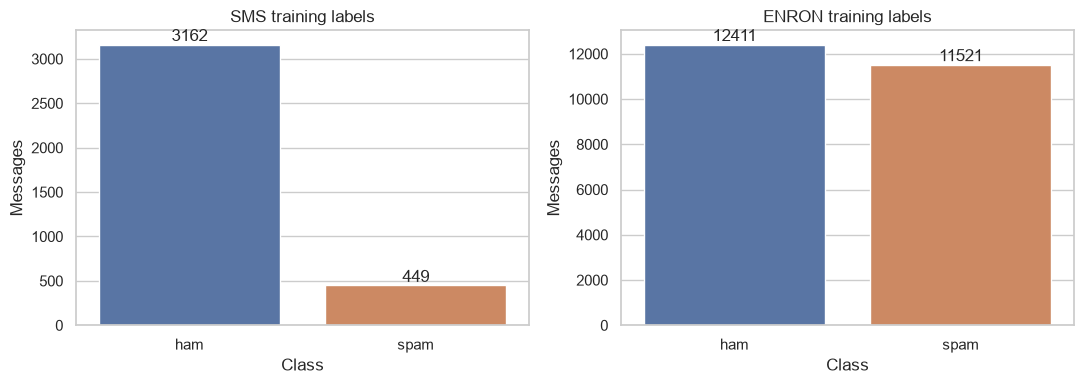

In [5]:
train_eda = eda.query("split == 'train'").copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for axis, dataset_name in zip(axes, ['sms', 'enron']):
    counts = (
        train_eda.query('dataset == @dataset_name')['label_name']
        .value_counts()
        .reindex(['ham', 'spam'])
    )
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, ax=axis)
    axis.set_title(f'{dataset_name.upper()} training labels')
    axis.set_xlabel('Class')
    axis.set_ylabel('Messages')
    for container in axis.containers:
        axis.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

## 4. Message-length domain shift

SMS and email have substantially different length distributions. The logarithmic scale makes both visible and highlights a domain shift that may affect transfer performance.

In [6]:
length_summary = (
    train_eda.groupby(['dataset', 'label_name'])[['characters', 'words']]
    .agg(['median', lambda values: values.quantile(0.95)])
)
length_summary.columns = [
    '_'.join([left, 'median' if right == 'median' else 'p95'])
    for left, right in length_summary.columns
]
length_summary.round(0)

characters_median  characters_p95  words_median  words_p95
dataset label_name                                                            
enron   ham                     784.0          4392.0         172.0      942.0
        spam                    647.0          5082.0         137.0      941.0
sms     ham                      53.0           158.0          11.0       33.0
        spam                    148.0           162.0          25.0       31.0

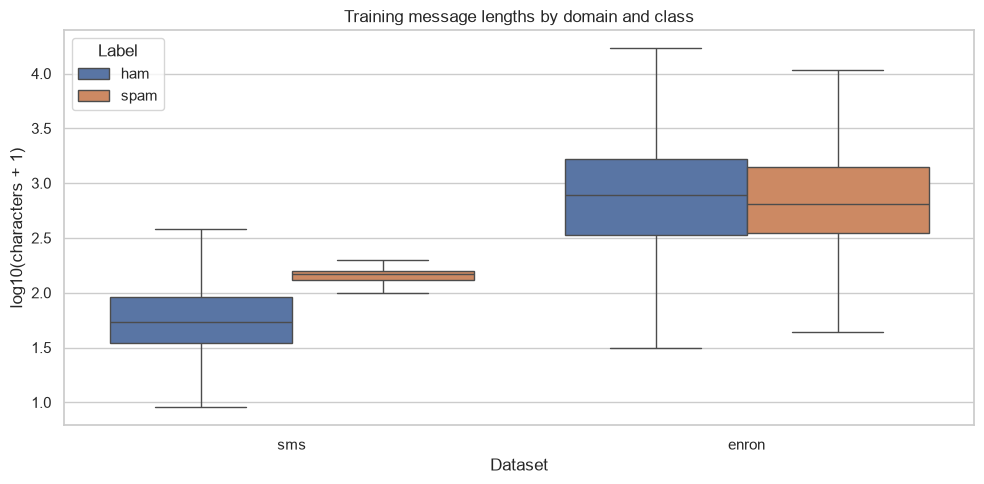

In [7]:
plot_data = train_eda.copy()
plot_data['log10_characters'] = np.log10(plot_data['characters'] + 1)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=plot_data,
    x='dataset',
    y='log10_characters',
    hue='label_name',
    showfliers=False,
)
plt.title('Training message lengths by domain and class')
plt.xlabel('Dataset')
plt.ylabel('log10(characters + 1)')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

## 5. Representative examples

Only short previews are displayed to keep the notebook readable.

In [8]:
examples = (
    train_eda.groupby(['dataset', 'label_name'], group_keys=False)
    .sample(n=2, random_state=RANDOM_STATE)
    .loc[:, ['dataset', 'label_name', 'text']]
)
examples['text_preview'] = examples['text'].str.slice(0, 240)
examples.drop(columns='text').sort_values(['dataset', 'label_name'])

,dataset,label_name,text_preview
24367,enron,ham,jake ? - tech . gif - 3 - 21 - 00 8 ' 57 ' 27 pm . jpg - 3 - 21 - 00 8 ' 53 ' 26 pm . jpg - 3 - 21 - 00 8 ' 55 ' 03 ...
19520,enron,ham,"re : wharton business plan competition christie , look fwd to the trip . shirley is sending you my itinerary . when ..."
14532,enron,spam,titles from autocad and win xp up to 90 % off at hardin electronics browse search order my esoft community back to s...
12036,enron,spam,"these women want to date alright , here is the most massive , city by city guide of women that want to meeeeeeeeeeet..."
2611,sms,ham,Purity of friendship between two is not about smiling after reading the forwarded message..Its about smiling just by...
2868,sms,ham,Then get some cash together and I'll text jason
1749,sms,spam,"Dear Voucher Holder, To claim this weeks offer, at you PC please go to http://www.e-tlp.co.uk/expressoffer Ts&Cs app..."
1518,sms,spam,2/2 146tf150p


## 6. Cross-source overlap check

Exact overlap between the sources could inflate cross-domain performance. We compare normalized texts and confirm that SMS and Enron share no exact messages.

In [9]:
sms_keys = set(eda.query("dataset == 'sms'")['text'].str.casefold())
enron_keys = set(eda.query("dataset == 'enron'")['text'].str.casefold())
cross_source_overlap = sms_keys & enron_keys
print(f'Exact normalized texts shared by SMS and Enron: {len(cross_source_overlap):,}')

Exact normalized texts shared by SMS and Enron: 0


## Conclusion

- SMS contains 5,159 unique messages and about 12.4% are spam.
- The cleaned Enron training source contains 28,528 unique messages and about 48.1% are spam.
- Cleaning removes empty texts, exact duplicates, and Enron training messages that overlap with its preserved test set.
- Median length is 61 characters for SMS and roughly 710 characters for email.
- No exact normalized message is shared between the two sources.

The two main modeling risks are class imbalance and document-length domain shift. Notebook 2 builds a TF-IDF logistic-regression baseline before a neural model is considered.